In [34]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [36]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

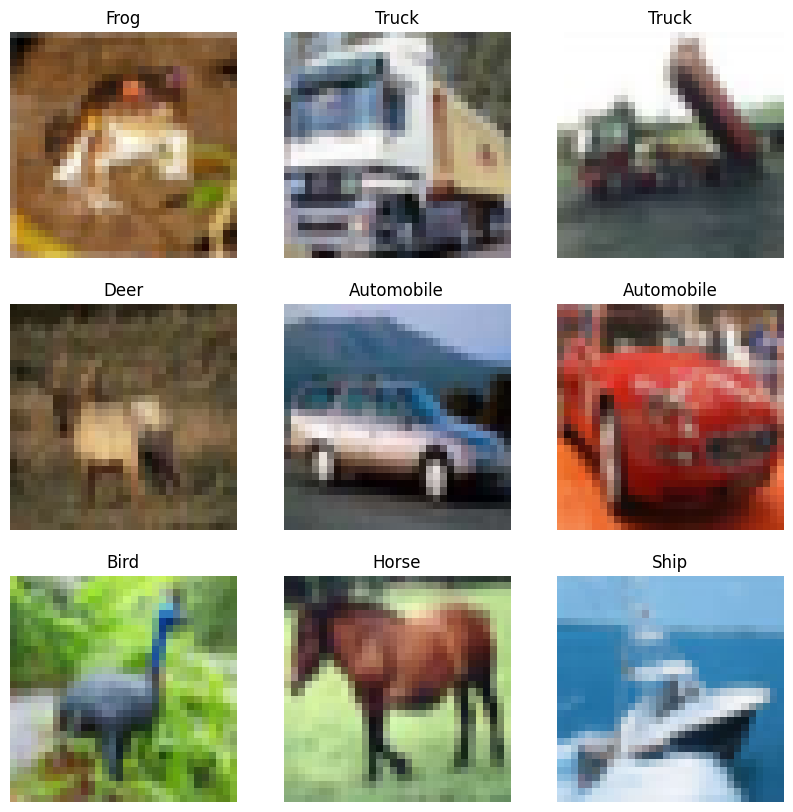

In [39]:
y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

In [40]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [41]:
print(f"Розмір train: {x_train.shape}")
print(f"Розмір test: {x_test.shape}")

Розмір train: (50000, 32, 32, 3)
Розмір test: (10000, 32, 32, 3)


In [8]:
model_dense = keras.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [9]:
model_dense.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
history_dense = model_dense.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=64,
    verbose=1
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - accuracy: 0.3114 - loss: 1.8953 - val_accuracy: 0.3664 - val_loss: 1.7605
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.3881 - loss: 1.6987 - val_accuracy: 0.3890 - val_loss: 1.7089
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.4203 - loss: 1.6123 - val_accuracy: 0.4301 - val_loss: 1.5993
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.4426 - loss: 1.5582 - val_accuracy: 0.4168 - val_loss: 1.6282
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.4572 - loss: 1.5109 - val_accuracy: 0.4544 - val_loss: 1.5513
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.4710 - loss: 1.4746 - val_accuracy: 0.4503 - val_loss: 1.5688
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.4820 - loss: 1.4441 - val_accuracy: 0.4602 - val_loss: 1.5212
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.4949 - loss: 1.4124 - 

Бачимо, що навчання йде, але доволі повільно (точність зросла з 31% всього до 51%). Точність на валідаційних даних після 10 епох становить лише 47%, це низький результат, може свідчити про те, що щільна архітектура нейронної мережі погано підходить для класифікації в цьому датасеті. Також є помірне перенавчання (стає явним після 9 епохи), розрив між тренувальною та валідаційною точністю поступово збільшується (спершу валідаційна точність навіть перевищувала тренувальну, але вже після 4 епохи відставала). До того ж, в нас нема строгого зросту валідаційної точності, вона коливається, а це означає що модель чутлива до конкретних батчів даних і не формує стабільних уявлень про ознаки об'єктів.

In [11]:
test_loss_dense, test_acc_dense = model_dense.evaluate(x_test, y_test, verbose=0)
print(f"Точність щільної мережі: {test_acc_dense:.4f}")

Точність щільної мережі: 0.4777


Модель показала практично ту саму точність, що й на валідації (47%), тобто покращення немає

In [20]:
model_cnn = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [22]:
model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
history_cnn = model_cnn.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=64,
    verbose=1
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 98s 152ms/step - accuracy: 0.2355 - loss: 2.2404 - val_accuracy: 0.3595 - val_loss: 1.7731
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 102s 164ms/step - accuracy: 0.4286 - loss: 1.5396 - val_accuracy: 0.5004 - val_loss: 1.3779
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 90s 144ms/step - accuracy: 0.5304 - loss: 1.3025 - val_accuracy: 0.5664 - val_loss: 1.2085
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 155ms/step - accuracy: 0.5869 - loss: 1.1629 - val_accuracy: 0.6485 - val_loss: 0.9825
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 89s 143ms/step - accuracy: 0.6295 - loss: 1.0533 - val_accuracy: 0.6799 - val_loss: 0.9005
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 92s 148ms/step - accuracy: 0.6631 - loss: 0.9639 - val_accuracy: 0.7014 - val_loss: 0.8372
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 89s 142ms/step - accuracy: 0.6884 - loss: 0.9015 - val_accuracy: 0.7273 - val_loss: 0.7792
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 90s 144ms/step - accuracy: 0.7031 - loss: 

Бачим значно ліпші результати! Тренувальна точність зросла з 23% на першій епосі до 73% на десятій, модель вчиться і ефективно засвоює дані. Валідаційна точність зросла з 36% до 76% за ті ж 10 епох, що на 28.3 відсоткових пункти вище за результат щільної мережі. Перенавчання немає, принаймні я не бачу, валідаційна точність стабільно зростає протягом усіх 10 епох без жодного падіння. Більше того, починаючи з четвертої епохи, валідаційна точність постійно перевищує тренувальну. Валідаційна функція втрат також стабільно зменшується з 1.773 до 0.690, що підтверджує відсутність перенавчання. По часу ця модель вчиться значно довше (спершу в мене було 20 епох, але ноут не страшно сильно завис...), однак це є прийнятною ціною за суттєве покращення якості класифікації.

In [17]:
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(x_test, y_test, verbose=0)
print(f"Точність CNN мережі: {test_acc_cnn:.4f}")

Точність CNN мережі: 0.7459


Хороший результат, невелике падіння порівняно з валідацією, але це нормально і прийнятно. Модель CNN успішно узагальнює знання на нові дані з мінімальною втратою точності!

In [19]:
learning_rates = [0.001, 0.0005, 0.0001]
best_acc = 0
best_lr = None

for lr in learning_rates:
    print(f"Тестування learning rate: {lr}")
    model_temp = keras.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    
    optimizer = keras.optimizers.Adam(learning_rate=lr)
    model_temp.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    history_temp = model_temp.fit(x_train, y_train, epochs=10, validation_split=0.2, batch_size=128, verbose=0)
    val_acc = history_temp.history['val_accuracy'][-1]
    
    if val_acc > best_acc:
        best_acc = val_acc
        best_lr = lr
        model_best = model_temp
        history_best = history_temp

print(f"\nНайкращий learning rate: {best_lr} з точністю: {best_acc:.4f}")

Тестування learning rate: 0.001
Тестування learning rate: 0.0005
Тестування learning rate: 0.0001

Найкращий learning rate: 0.001 з точністю: 0.7045


Тестуєм три різні значення швидкості навчання оптимізатора Adam. Мабуть достатньо було 2-3 епох на кожен тест, бо зараз це працювало страшно довго (з очевидних причин). Потім найкращий варіант донавчити довше. Найкращу точність на валідаційних даних показала модель зі швидкістю навчання 0.001, досягнувши показника 70.45%, що є нижчим показником порівняно з попередньою згортковою мережею без додаткових шарів регуляризації. Швидше за все, для повного розкриття потенціалу BatchNormalization та Dropout потрібно збільшити кількість епох до 30-50, оскільки регуляризація запобігає швидкому перенавчанню, але водночас потребує більше часу для досягнення високої точності. 

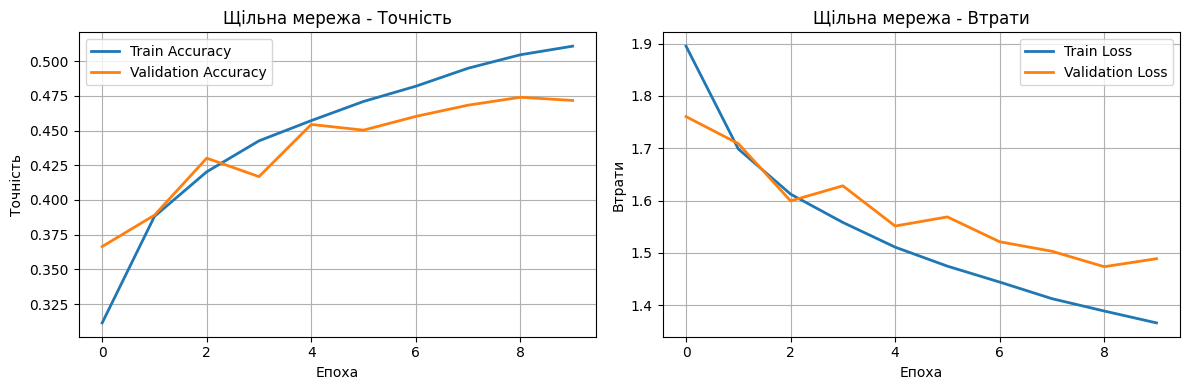

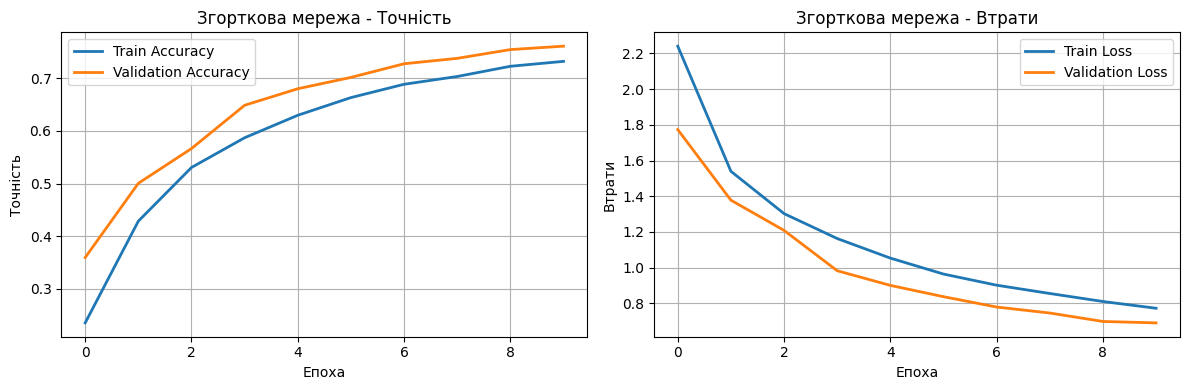

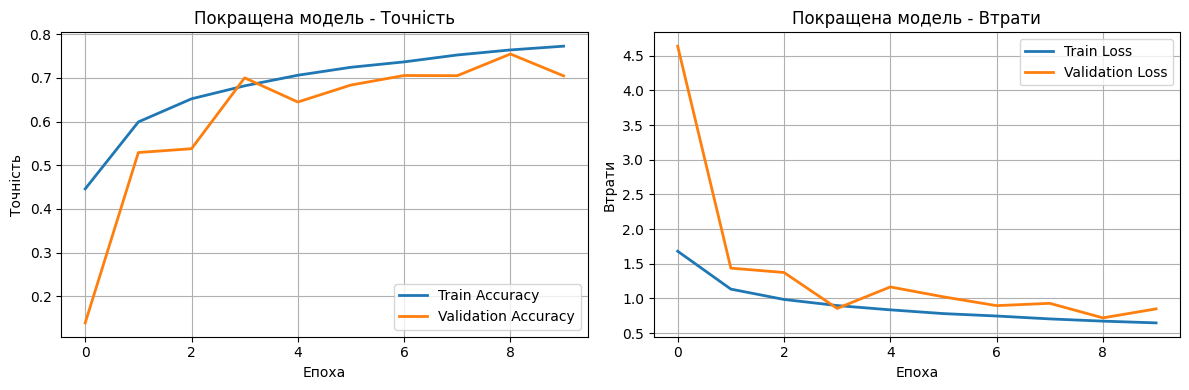

In [31]:
def plot_training_history(history, title="Модель"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_title(f'{title} - Точність')
    ax1.set_xlabel('Епоха')
    ax1.set_ylabel('Точність')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_title(f'{title} - Втрати')
    ax2.set_xlabel('Епоха')
    ax2.set_ylabel('Втрати')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history_dense, "Щільна мережа")
plot_training_history(history_cnn, "Згорткова мережа")
plot_training_history(history_best, "Покращена модель")